# Sentiment Analysis Evaluation
This notebook tests the sentiment analysis model on 12+ sentences and visualizes the results.

In [ ]:
%pip install transformers

In [1]:
# Import required libraries
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from app.sentiment import analyze_sentiment
from app.sentiment_hf import analyze_sentiment_hf

c:\Users\jackd\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\jackd\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\jackd\.cache\huggingface\hub\models--cardiffnlp--twitter-roberta-base-sentiment-latest. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mod

## Test Sentences
We will use 12 sentences: 4 positive, 4 negative, 4 neutral.

In [3]:
test_sentences = [
    ('I love this product!', 'positive'),
    ('This is fantastic, I am very happy.', 'positive'),
    ('Absolutely wonderful experience.', 'positive'),
    ('The service was excellent.', 'positive'),
    ('I hate this.', 'negative'),
    ('This is the worst thing ever.', 'negative'),
    ('I am very disappointed.', 'negative'),
    ('Terrible experience, will not return.', 'negative'),
    ('It is a product.', 'neutral'),
    ('The weather is average today.', 'neutral'),
    ('I went to the store.', 'neutral'),
    ('Nothing special happened.', 'neutral')
]

In [4]:
# Run predictions
results = []
for text, true_label in test_sentences:
    pred = analyze_sentiment(text)
    results.append({'text': text, 'true_label': true_label, 'predicted': pred.label, 'polarity': pred.polarity})
df = pd.DataFrame(results)
df

,text,true_label,predicted,polarity
0,I love this product!,positive,Positive,0.6250
1,"This is fantastic, I am very happy.",positive,Positive,0.7000
2,Absolutely wonderful experience.,positive,Positive,1.0000
3,The service was excellent.,positive,Positive,1.0000
4,I hate this.,negative,Negative,-0.8000
5,This is the worst thing ever.,negative,Negative,-1.0000
6,I am very disappointed.,negative,Negative,-0.9750
7,"Terrible experience, will not return.",negative,Negative,-1.0000
8,It is a product.,neutral,Neutral,0.0000
9,The weather is average today.,neutral,Neutral,-0.1500


## Visualize Sentiment Distribution
We will plot the distribution of predicted sentiment labels and polarity scores.

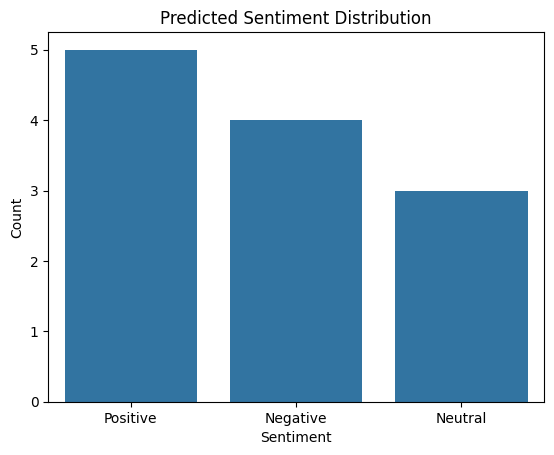

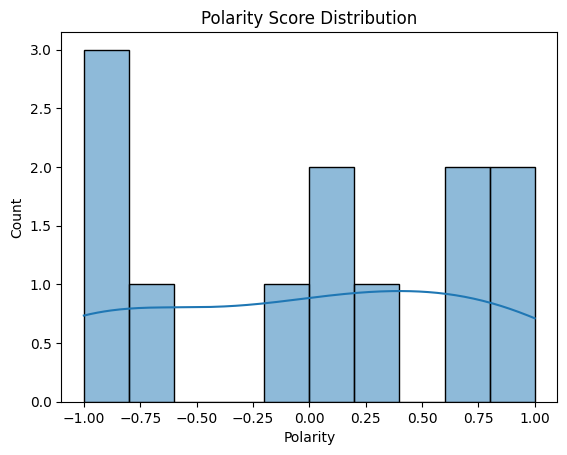

In [5]:
# Plot sentiment label distribution
sns.countplot(x='predicted', data=df)
plt.title('Predicted Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

# Plot polarity distribution
sns.histplot(df['polarity'], bins=10, kde=True)
plt.title('Polarity Score Distribution')
plt.xlabel('Polarity')
plt.ylabel('Count')
plt.show()

## Accuracy and Threshold Analysis
We will analyze accuracy as a function of polarity threshold, similar to the example visualization.

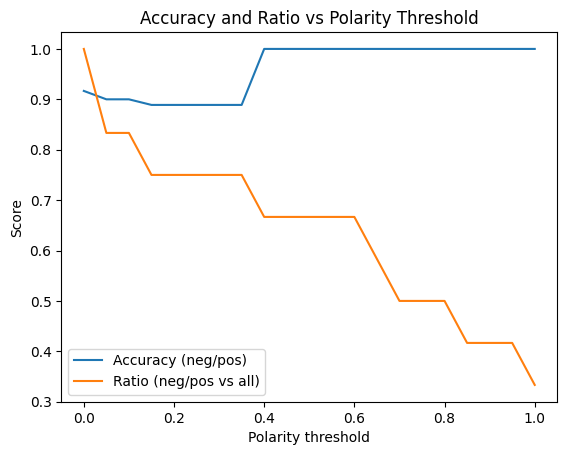

In [6]:
# Analyze accuracy vs polarity threshold
import numpy as np
thresholds = np.linspace(0, 1, 21)
accuracies = []
ratios = []
for t in thresholds:
    # Only count as positive/negative if abs(polarity) >= t
    mask = df['polarity'].abs() >= t
    filtered = df[mask]
    if len(filtered) == 0:
        accuracies.append(np.nan)
        ratios.append(0)
        continue
    acc = (filtered['true_label'].str.lower() == filtered['predicted'].str.lower()).mean()
    accuracies.append(acc)
    ratios.append(len(filtered) / len(df))
plt.plot(thresholds, accuracies, label='Accuracy (neg/pos)')
plt.plot(thresholds, ratios, label='Ratio (neg/pos vs all)')
plt.xlabel('Polarity threshold')
plt.ylabel('Score')
plt.title('Accuracy and Ratio vs Polarity Threshold')
plt.legend()
plt.show()

## Compare TextBlob and Hugging Face Results
We will run both models on the test sentences and compare their predictions.

In [7]:
# Run both models and compare
results = []
for text, true_label in test_sentences:
    tb_pred = analyze_sentiment(text)
    hf_pred = analyze_sentiment_hf(text)
    results.append({
        'text': text,
        'true_label': true_label,
        'textblob_label': tb_pred.label,
        'textblob_polarity': tb_pred.polarity,
        'hf_label': hf_pred['label'],
        'hf_score': hf_pred['score']
    })
df_compare = pd.DataFrame(results)
df_compare

,text,true_label,textblob_label,textblob_polarity,hf_label,hf_score
0,I love this product!,positive,Positive,0.6250,positive,0.9848
1,"This is fantastic, I am very happy.",positive,Positive,0.7000,positive,0.9861
2,Absolutely wonderful experience.,positive,Positive,1.0000,positive,0.9748
3,The service was excellent.,positive,Positive,1.0000,positive,0.9695
4,I hate this.,negative,Negative,-0.8000,negative,0.8900
5,This is the worst thing ever.,negative,Negative,-1.0000,negative,0.9459
6,I am very disappointed.,negative,Negative,-0.9750,negative,0.9006
7,"Terrible experience, will not return.",negative,Negative,-1.0000,negative,0.9288
8,It is a product.,neutral,Neutral,0.0000,neutral,0.7947
9,The weather is average today.,neutral,Neutral,-0.1500,negative,0.6513


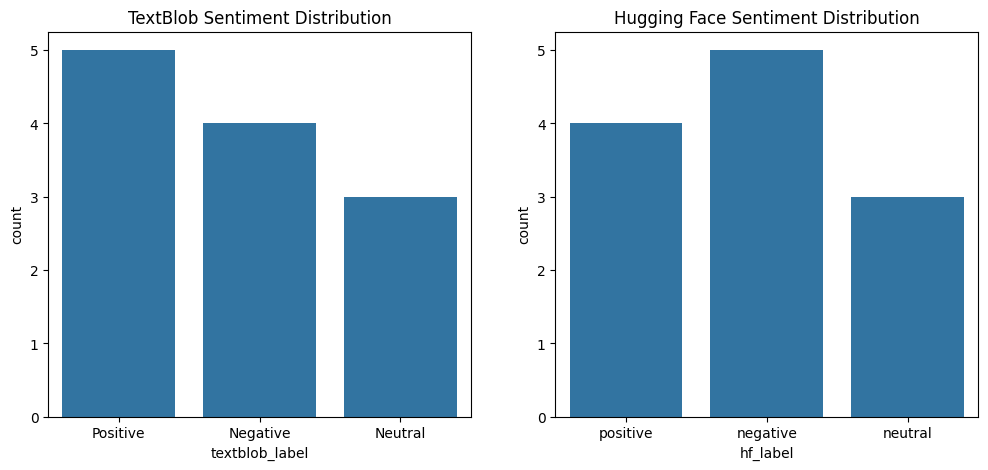

Agreement between models: 83.3%


,text,true_label,textblob_label,textblob_polarity,hf_label,hf_score
9,The weather is average today.,neutral,Neutral,-0.1500,negative,0.6513
11,Nothing special happened.,neutral,Positive,0.3571,neutral,0.7465


In [8]:
# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x='textblob_label', data=df_compare, ax=axes[0])
axes[0].set_title('TextBlob Sentiment Distribution')
sns.countplot(x='hf_label', data=df_compare, ax=axes[1])
axes[1].set_title('Hugging Face Sentiment Distribution')
plt.show()

# Show agreement/disagreement
agreement = (df_compare['textblob_label'].str.lower() == df_compare['hf_label'].str.lower())
agree_pct = agreement.mean() * 100
print(f"Agreement between models: {agree_pct:.1f}%")
df_compare[~agreement]